# Credit Card Fraud Detection — Imbalanced Classification

**Author:** Khushi  
**Dataset:** [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/mlg-ulb/creditcardfraud)  
**Goal:** Build and compare fraud detection models on a severely imbalanced dataset (0.17% fraud rate), mirroring real-world financial crime detection challenges.

## Project structure
1. Setup and data loading
2. Exploratory Data Analysis (EDA)
3. Preprocessing and feature engineering
4. Baseline model — Logistic Regression
5. Imbalance handling — Class weights vs SMOTE
6. Main model — XGBoost with tuning
7. Model evaluation — banking-relevant metrics (KS statistic, Precision-Recall AUC)
8. SHAP explainability
9. Champion-challenger comparison
10. Business interpretation and threshold analysis

## 1. Setup and data loading

In [1]:
import sys
print(sys.executable)

/usr/local/bin/python3


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score,
    roc_curve, f1_score, precision_score, recall_score
)
from sklearn.pipeline import Pipeline

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import shap

# Plot styling
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
COLORS = {'fraud': '#E74C3C', 'legit': '#2ECC71', 'model1': '#3498DB', 'model2': '#E67E22'}

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [3]:
# Update this path to wherever you saved the file in Drive
DATA_PATH = '/Users/khushi/DS Fraud Project/creditcard.csv'

df = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

Dataset loaded: 284,807 rows × 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Exploratory Data Analysis

Before touching any model, we need to understand what we are working with.
Key questions: How imbalanced is the dataset? Are there missing values? What do the distributions look like?

In [4]:
# ── Basic info ──────────────────────────────────────────────────────────────
print('=== Dataset Overview ===')
print(f'Shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nData types:\n{df.dtypes.value_counts()}')
print(f'\nTarget distribution:')
print(df['Class'].value_counts())
print(f'\nFraud rate: {df["Class"].mean() * 100:.4f}%')

=== Dataset Overview ===
Shape: (284807, 31)
Missing values: 0

Data types:
float64    30
int64       1
Name: count, dtype: int64

Target distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


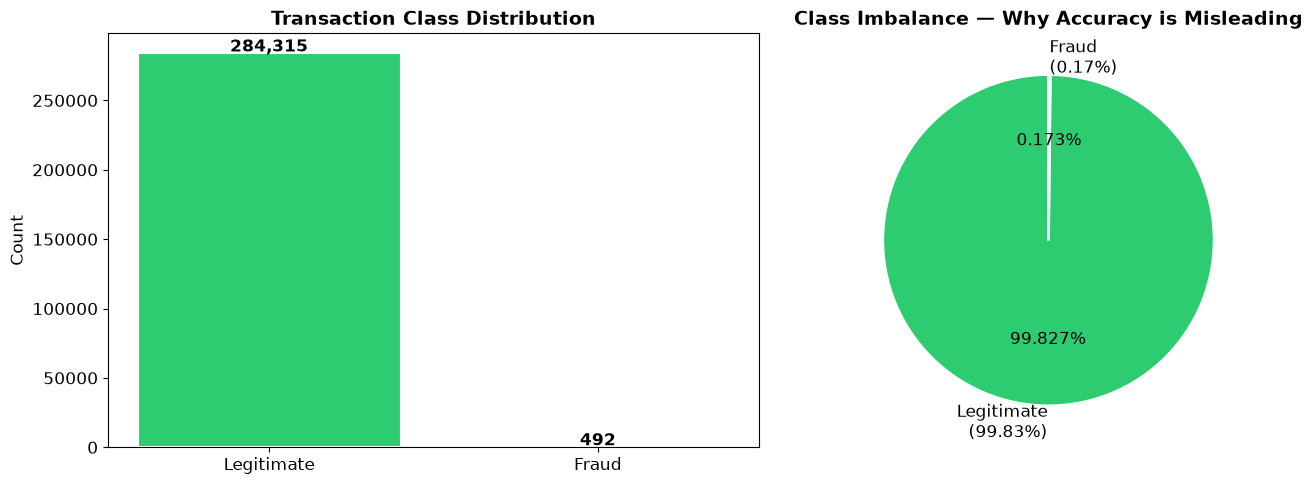


Key insight: A model that predicts EVERY transaction as legitimate would achieve
99.83% accuracy — but catch ZERO fraud cases. This is why we use Precision-Recall AUC and KS statistic.


In [5]:
# ── Class imbalance visualisation ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
counts = df['Class'].value_counts()
axes[0].bar(['Legitimate', 'Fraud'], counts.values,
            color=[COLORS['legit'], COLORS['fraud']], edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Percentage pie
axes[1].pie(counts.values, labels=['Legitimate\n(99.83%)', 'Fraud\n(0.17%)'],
            colors=[COLORS['legit'], COLORS['fraud']],
            autopct='%1.3f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Imbalance — Why Accuracy is Misleading', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nKey insight: A model that predicts EVERY transaction as legitimate would achieve')
print(f'99.83% accuracy — but catch ZERO fraud cases. This is why we use Precision-Recall AUC and KS statistic.')

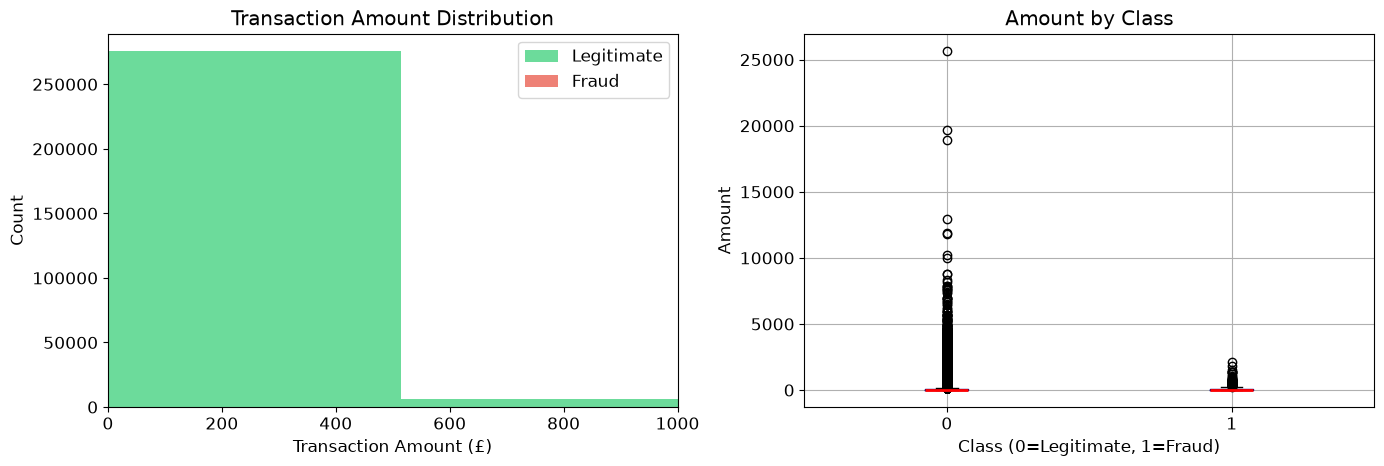

Legitimate transactions — Mean: £88.29, Median: £22.00, Max: £25691.16
Fraud transactions     — Mean: £122.21, Median: £9.25, Max: £2125.87


In [6]:
# ── Transaction amount distribution by class ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']

axes[0].hist(legit, bins=50, color=COLORS['legit'], alpha=0.7, label='Legitimate')
axes[0].hist(fraud, bins=50, color=COLORS['fraud'], alpha=0.7, label='Fraud')
axes[0].set_xlabel('Transaction Amount (£)')
axes[0].set_ylabel('Count')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()
axes[0].set_xlim(0, 1000)  # Focus on typical range

# Box plots
df.boxplot(column='Amount', by='Class', ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Amount by Class')
axes[1].set_xlabel('Class (0=Legitimate, 1=Fraud)')
axes[1].set_ylabel('Amount')
plt.suptitle('')

plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Legitimate transactions — Mean: £{legit.mean():.2f}, Median: £{legit.median():.2f}, Max: £{legit.max():.2f}')
print(f'Fraud transactions     — Mean: £{fraud.mean():.2f}, Median: £{fraud.median():.2f}, Max: £{fraud.max():.2f}')

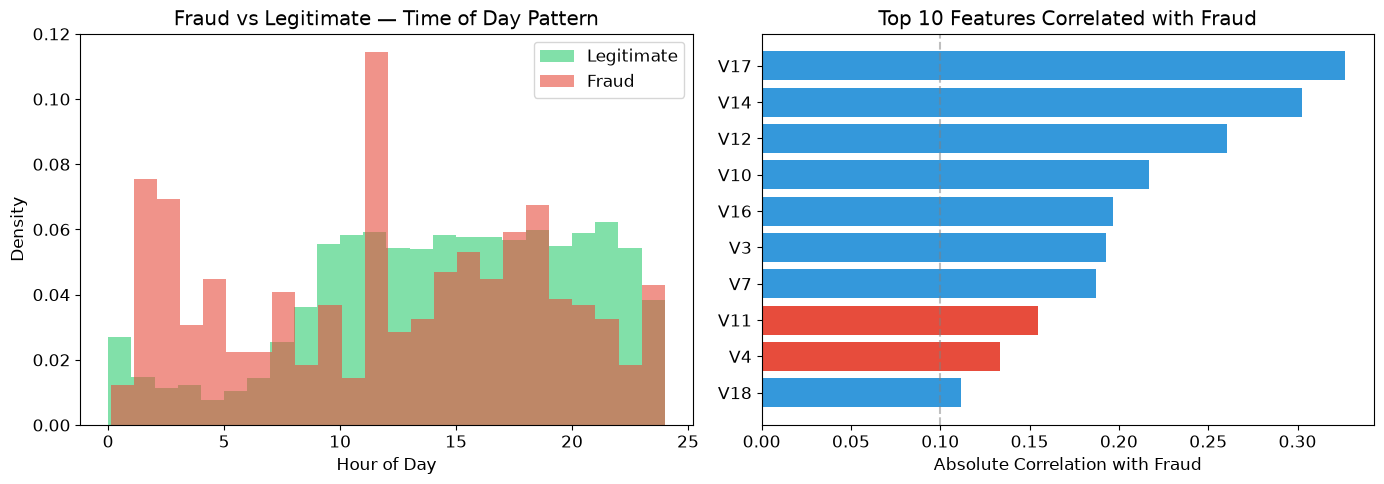

Top 10 features by correlation with fraud label:
V17    0.326481
V14    0.302544
V12    0.260593
V10    0.216883
V16    0.196539
V3     0.192961
V7     0.187257
V11    0.154876
V4     0.133447
V18    0.111485


In [7]:
# ── Transaction time pattern ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convert seconds to hours
df['Hour'] = (df['Time'] / 3600) % 24

axes[0].hist(df[df['Class']==0]['Hour'], bins=24, color=COLORS['legit'],
             alpha=0.6, label='Legitimate', density=True)
axes[0].hist(df[df['Class']==1]['Hour'], bins=24, color=COLORS['fraud'],
             alpha=0.6, label='Fraud', density=True)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Density')
axes[0].set_title('Fraud vs Legitimate — Time of Day Pattern')
axes[0].legend()

# Correlation heatmap of top features with Class
correlations = df.corr()['Class'].drop('Class').abs().sort_values(ascending=False)
top_features = correlations.head(10)

axes[1].barh(top_features.index[::-1], top_features.values[::-1],
             color=['#E74C3C' if c > 0 else '#3498DB'
                    for c in df.corr()['Class'].drop('Class').loc[top_features.index[::-1]]])
axes[1].set_xlabel('Absolute Correlation with Fraud')
axes[1].set_title('Top 10 Features Correlated with Fraud')
axes[1].axvline(x=0.1, color='gray', linestyle='--', alpha=0.5, label='0.1 threshold')

plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by correlation with fraud label:')
print(top_features.to_string())

## 3. Preprocessing and Feature Engineering

Key steps:
- Scale `Amount` and `Time` (V1-V28 are already PCA-transformed and scaled)
- Create a derived feature: `Amount_log` — log transform reduces the effect of extreme values
- Chronological train/test split — **critical for fraud models**, never random split on time-ordered data

In [8]:
# ── Feature engineering ─────────────────────────────────────────────────────
df['Amount_log'] = np.log1p(df['Amount'])  # log(1 + Amount) handles zero values
df['Amount_scaled'] = StandardScaler().fit_transform(df[['Amount']])
df['Time_scaled'] = StandardScaler().fit_transform(df[['Time']])

# Feature set — drop original Amount and Time, keep scaled versions
feature_cols = [c for c in df.columns
                if c not in ['Class', 'Amount', 'Time', 'Hour']]
print(f'Features used: {len(feature_cols)}')
print(feature_cols)

Features used: 31
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_log', 'Amount_scaled', 'Time_scaled']


In [9]:
# ── Chronological train/test split ──────────────────────────────────────────
# IMPORTANT: Never use random split for fraud data — it leaks future info into training
# Sort by Time (already sorted, but making it explicit)
df_sorted = df.sort_values('Time').reset_index(drop=True)

split_idx = int(len(df_sorted) * 0.80)
train_df = df_sorted.iloc[:split_idx]
test_df  = df_sorted.iloc[split_idx:]

X_train = train_df[feature_cols]
y_train = train_df['Class']
X_test  = test_df[feature_cols]
y_test  = test_df['Class']

print('=== Chronological Split ===')
print(f'Training set:  {X_train.shape[0]:,} rows | Fraud rate: {y_train.mean()*100:.3f}%')
print(f'Test set:      {X_test.shape[0]:,} rows  | Fraud rate: {y_test.mean()*100:.3f}%')
print()
print('Why chronological split matters:')
print('A random split would leak future transactions into the training set.')
print('In production, the model only ever sees past data — so our test set must')
print('simulate that by using the most recent 20% of transactions.')

=== Chronological Split ===
Training set:  227,845 rows | Fraud rate: 0.183%
Test set:      56,962 rows  | Fraud rate: 0.132%

Why chronological split matters:
A random split would leak future transactions into the training set.
In production, the model only ever sees past data — so our test set must
simulate that by using the most recent 20% of transactions.


## 4. Baseline Model — Logistic Regression

Always start simple. Logistic Regression:
- Is fully interpretable (coefficients have direct meaning)
- Is fast enough for real-time scoring
- Is preferred by model risk teams in regulated banks for its explainability
- Sets the performance benchmark every subsequent model must beat

In [10]:
# ── Helper functions ────────────────────────────────────────────────────────

def ks_statistic(y_true, y_prob):
    """KS statistic — standard banking model validation metric.
    Measures maximum separation between cumulative distributions
    of fraud and legitimate transactions.
    KS > 0.4 is generally considered a good fraud model.
    """
    df_ks = pd.DataFrame({'y_true': y_true, 'y_prob': y_prob})
    df_ks = df_ks.sort_values('y_prob', ascending=False)
    df_ks['cum_fraud'] = (df_ks['y_true'] == 1).cumsum() / (df_ks['y_true'] == 1).sum()
    df_ks['cum_legit'] = (df_ks['y_true'] == 0).cumsum() / (df_ks['y_true'] == 0).sum()
    ks = (df_ks['cum_fraud'] - df_ks['cum_legit']).abs().max()
    return ks

def evaluate_model(name, y_true, y_prob, threshold=0.5):
    """Full evaluation suite using banking-relevant metrics."""
    y_pred = (y_prob >= threshold).astype(int)

    pr_auc   = average_precision_score(y_true, y_prob)
    roc_auc  = roc_auc_score(y_true, y_prob)
    ks       = ks_statistic(y_true, y_prob)
    recall   = recall_score(y_true, y_pred)
    precision= precision_score(y_true, y_pred)
    f1       = f1_score(y_true, y_pred)

    print(f'\n{'='*50}')
    print(f'  {name}')
    print(f'{'='*50}')
    print(f'  Precision-Recall AUC : {pr_auc:.4f}  ← PRIMARY METRIC for imbalanced fraud')
    print(f'  KS Statistic         : {ks:.4f}  ← Standard banking validation metric')
    print(f'  ROC-AUC              : {roc_auc:.4f}')
    print(f'  Recall (Sensitivity) : {recall:.4f}  ← % of actual frauds caught')
    print(f'  Precision            : {precision:.4f}  ← % of flagged that are real fraud')
    print(f'  F1 Score             : {f1:.4f}')
    print(f'  Threshold used       : {threshold}')

    total_flagged = y_pred.sum()
    fraud_caught  = ((y_pred == 1) & (y_true == 1)).sum()
    false_alarms  = ((y_pred == 1) & (y_true == 0)).sum()
    print(f'\n  At threshold {threshold}:')
    print(f'  Total flagged        : {total_flagged:,}')
    print(f'  Real fraud caught    : {fraud_caught}')
    print(f'  False alarms (FP)    : {false_alarms:,}')

    return {'name': name, 'pr_auc': pr_auc, 'ks': ks, 'roc_auc': roc_auc,
            'recall': recall, 'precision': precision, 'f1': f1}

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Legit', 'Predicted Fraud'],
                yticklabels=['Actual Legit', 'Actual Fraud'],
                annot_kws={'size': 14})
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{title.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Helper functions defined.')

Helper functions defined.


Training baseline Logistic Regression...

  Logistic Regression (Baseline)
  Precision-Recall AUC : 0.7613  ← PRIMARY METRIC for imbalanced fraud
  KS Statistic         : 0.8847  ← Standard banking validation metric
  ROC-AUC              : 0.9861
  Recall (Sensitivity) : 0.8933  ← % of actual frauds caught
  Precision            : 0.0676  ← % of flagged that are real fraud
  F1 Score             : 0.1257
  Threshold used       : 0.5

  At threshold 0.5:
  Total flagged        : 991
  Real fraud caught    : 67
  False alarms (FP)    : 924


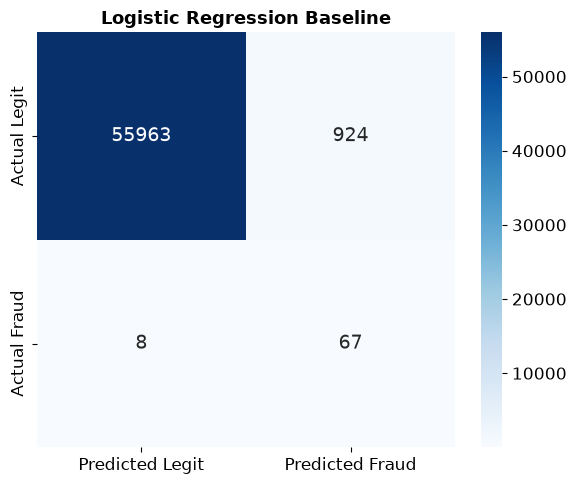

In [11]:
# ── Baseline: Logistic Regression with class weights ────────────────────────
print('Training baseline Logistic Regression...')

lr_baseline = LogisticRegression(
    class_weight='balanced',   # Automatically adjusts weights inversely to class frequencies
    max_iter=1000,
    random_state=42,
    solver='lbfgs'
)

lr_baseline.fit(X_train, y_train)
lr_probs = lr_baseline.predict_proba(X_test)[:, 1]

results_lr = evaluate_model('Logistic Regression (Baseline)', y_test, lr_probs)
plot_confusion_matrix(y_test, (lr_probs >= 0.5).astype(int), 'Logistic Regression Baseline')

## 5. Imbalance Handling — Comparing Class Weights vs SMOTE

Two standard approaches to handling severe class imbalance:
- **Class weights**: Tell the model to penalise misclassifying the minority class more heavily. Simple, fast, no synthetic data.
- **SMOTE (Synthetic Minority Oversampling Technique)**: Creates synthetic fraud examples by interpolating between existing fraud cases.

In banking, class weights are usually preferred because synthetic fraud transactions can mislead models about real fraud behaviour patterns.

In [12]:
# ── SMOTE oversampling pipeline ─────────────────────────────────────────────
print('Training Logistic Regression with SMOTE...')

smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('model', LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs'))
])

smote_pipeline.fit(X_train, y_train)
smote_probs = smote_pipeline.predict_proba(X_test)[:, 1]

results_smote = evaluate_model('Logistic Regression + SMOTE', y_test, smote_probs)

# Compare class weights vs SMOTE
print('\n=== Comparison: Class Weights vs SMOTE ===')
print(f'                       Class Weights    SMOTE')
print(f'Precision-Recall AUC : {results_lr["pr_auc"]:.4f}          {results_smote["pr_auc"]:.4f}')
print(f'KS Statistic         : {results_lr["ks"]:.4f}          {results_smote["ks"]:.4f}')
print(f'Recall               : {results_lr["recall"]:.4f}          {results_smote["recall"]:.4f}')
print(f'Precision            : {results_lr["precision"]:.4f}          {results_smote["precision"]:.4f}')
print()
print('Banking context note: In regulated environments, class weights are generally')
print('preferred over SMOTE because synthetic transactions may not reflect real fraud')
print('behaviour and can cause models to miss novel fraud patterns.')

Training Logistic Regression with SMOTE...

  Logistic Regression + SMOTE
  Precision-Recall AUC : 0.7700  ← PRIMARY METRIC for imbalanced fraud
  KS Statistic         : 0.8937  ← Standard banking validation metric
  ROC-AUC              : 0.9857
  Recall (Sensitivity) : 0.8800  ← % of actual frauds caught
  Precision            : 0.0656  ← % of flagged that are real fraud
  F1 Score             : 0.1221
  Threshold used       : 0.5

  At threshold 0.5:
  Total flagged        : 1,006
  Real fraud caught    : 66
  False alarms (FP)    : 940

=== Comparison: Class Weights vs SMOTE ===
                       Class Weights    SMOTE
Precision-Recall AUC : 0.7613          0.7700
KS Statistic         : 0.8847          0.8937
Recall               : 0.8933          0.8800
Precision            : 0.0676          0.0656

Banking context note: In regulated environments, class weights are generally
preferred over SMOTE because synthetic transactions may not reflect real fraud
behaviour and can cause

## 6. Main Model — XGBoost

XGBoost is the industry standard for tabular fraud data:
- Handles non-linear relationships the logistic regression baseline misses
- Built-in handling for class imbalance via `scale_pos_weight`
- Native feature importance
- Compatible with SHAP for interpretability required in regulated banking

scale_pos_weight = 227,428 / 417 = 545.4
This tells XGBoost to weight each fraud case as if it were ~577 legitimate cases

[0]	validation_0-aucpr:0.62672
[50]	validation_0-aucpr:0.75367
[100]	validation_0-aucpr:0.85460
[150]	validation_0-aucpr:0.87717
[200]	validation_0-aucpr:0.88441
[250]	validation_0-aucpr:0.88737
[299]	validation_0-aucpr:0.88839

  XGBoost (Main Model)
  Precision-Recall AUC : 0.8024  ← PRIMARY METRIC for imbalanced fraud
  KS Statistic         : 0.8799  ← Standard banking validation metric
  ROC-AUC              : 0.9789
  Recall (Sensitivity) : 0.7467  ← % of actual frauds caught
  Precision            : 0.9032  ← % of flagged that are real fraud
  F1 Score             : 0.8175
  Threshold used       : 0.5

  At threshold 0.5:
  Total flagged        : 62
  Real fraud caught    : 56
  False alarms (FP)    : 6


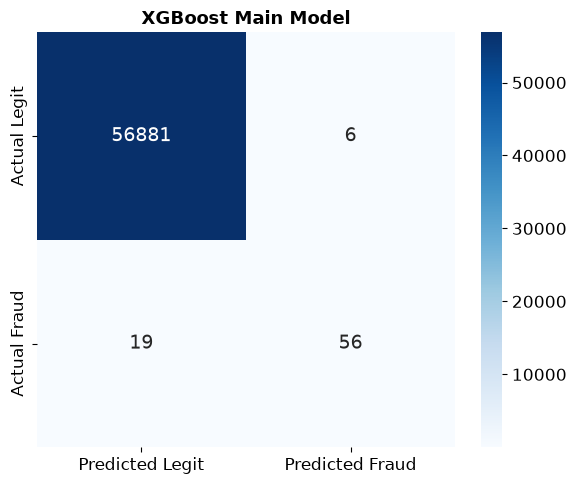

In [13]:
# ── XGBoost with scale_pos_weight ───────────────────────────────────────────
# scale_pos_weight = count(negative) / count(positive) — standard for imbalanced classification
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count

print(f'scale_pos_weight = {neg_count:,} / {pos_count} = {scale_pos_weight:.1f}')
print('This tells XGBoost to weight each fraud case as if it were ~577 legitimate cases')
print()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,      # L1 regularisation
    reg_lambda=1.0,     # L2 regularisation
    use_label_encoder=False,
    eval_metric='aucpr',  # Optimise for PR-AUC — correct for imbalanced data
    random_state=42,
    n_jobs=-1
)

# Early stopping to prevent overfitting
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=50
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
results_xgb = evaluate_model('XGBoost (Main Model)', y_test, xgb_probs)
plot_confusion_matrix(y_test, (xgb_probs >= 0.5).astype(int), 'XGBoost Main Model')

## 7. Model Evaluation — Banking-Relevant Metrics

In a real fraud team, we evaluate models using:
1. **Precision-Recall AUC** — primary metric for imbalanced fraud data
2. **KS Statistic** — standard banking model validation metric
3. **Precision-Recall curve** — shows the trade-off at every possible threshold
4. **Threshold analysis** — the business chooses the operating point, not the modeller

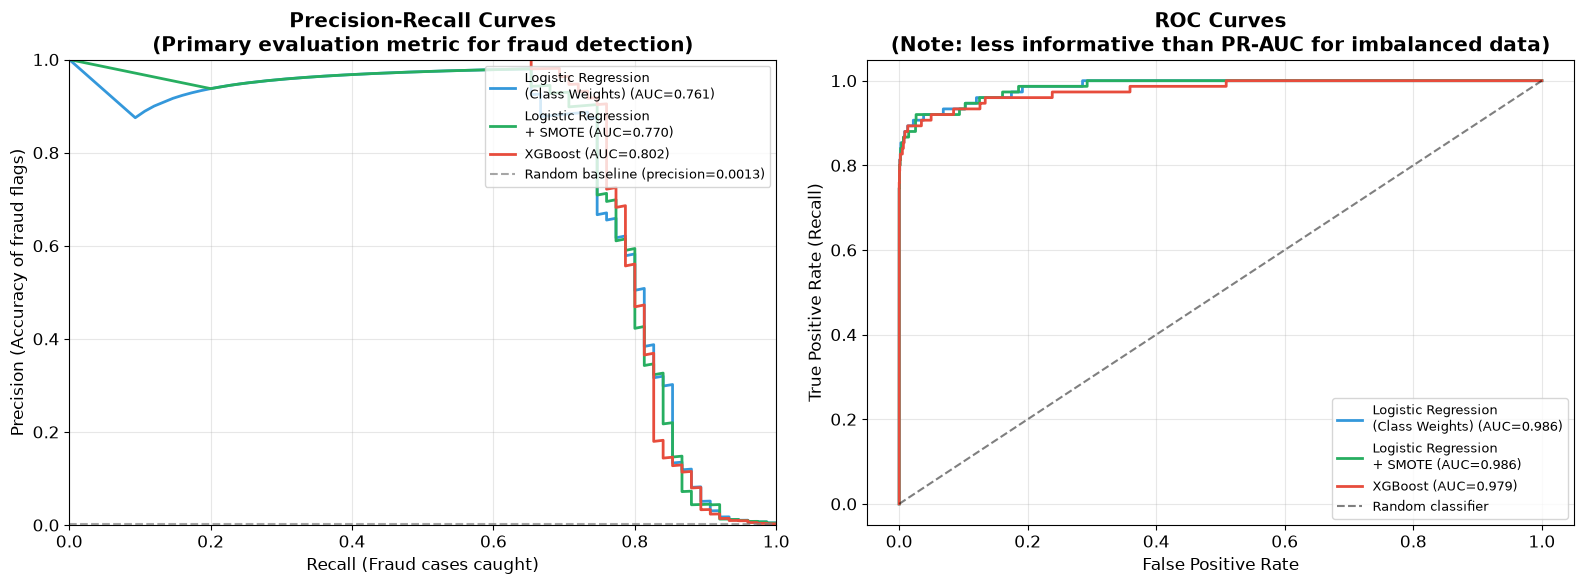

In [14]:
# ── Precision-Recall curves for all models ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_to_compare = [
    ('Logistic Regression\n(Class Weights)', lr_probs, '#3498DB'),
    ('Logistic Regression\n+ SMOTE',         smote_probs, '#27AE60'),
    ('XGBoost',                              xgb_probs, '#E74C3C'),
]

# Precision-Recall curves
for name, probs, color in models_to_compare:
    p, r, _ = precision_recall_curve(y_test, probs)
    auc_val = average_precision_score(y_test, probs)
    axes[0].plot(r, p, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

baseline_precision = y_test.mean()
axes[0].axhline(y=baseline_precision, color='gray', linestyle='--',
                alpha=0.7, label=f'Random baseline (precision={baseline_precision:.4f})')
axes[0].set_xlabel('Recall (Fraud cases caught)')
axes[0].set_ylabel('Precision (Accuracy of fraud flags)')
axes[0].set_title('Precision-Recall Curves\n(Primary evaluation metric for fraud detection)', fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# ROC curves
for name, probs, color in models_to_compare:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc_val = roc_auc_score(y_test, probs)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})', color=color, linewidth=2)

axes[1].plot([0,1],[0,1], 'k--', alpha=0.5, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].set_title('ROC Curves\n(Note: less informative than PR-AUC for imbalanced data)', fontweight='bold')
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

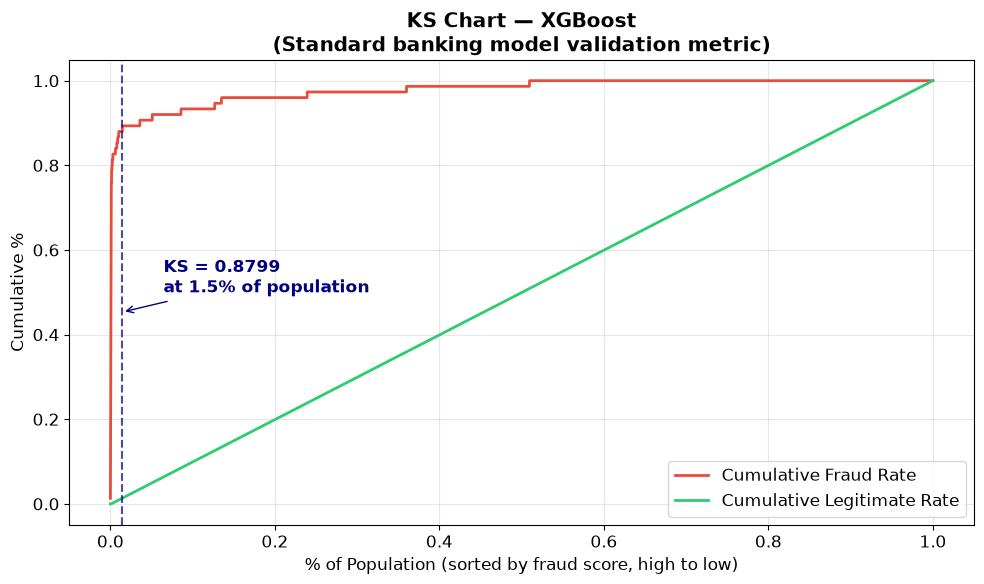

KS Statistic: 0.8799 — GOOD model discrimination


In [15]:
# ── KS Statistic plot ───────────────────────────────────────────────────────
def plot_ks_chart(y_true, y_prob, model_name):
    df_ks = pd.DataFrame({'y_true': y_true.values, 'y_prob': y_prob})
    df_ks = df_ks.sort_values('y_prob', ascending=False).reset_index(drop=True)
    df_ks['pct_pop']   = (df_ks.index + 1) / len(df_ks)
    df_ks['cum_fraud'] = (df_ks['y_true'] == 1).cumsum() / (df_ks['y_true'] == 1).sum()
    df_ks['cum_legit'] = (df_ks['y_true'] == 0).cumsum() / (df_ks['y_true'] == 0).sum()
    df_ks['ks_diff']   = df_ks['cum_fraud'] - df_ks['cum_legit']
    ks_val = df_ks['ks_diff'].max()
    ks_pct = df_ks.loc[df_ks['ks_diff'].idxmax(), 'pct_pop']

    plt.figure(figsize=(10, 6))
    plt.plot(df_ks['pct_pop'], df_ks['cum_fraud'],
             label='Cumulative Fraud Rate', color=COLORS['fraud'], linewidth=2)
    plt.plot(df_ks['pct_pop'], df_ks['cum_legit'],
             label='Cumulative Legitimate Rate', color=COLORS['legit'], linewidth=2)
    plt.axvline(x=ks_pct, color='navy', linestyle='--', alpha=0.7)
    plt.annotate(f'KS = {ks_val:.4f}\nat {ks_pct*100:.1f}% of population',
                 xy=(ks_pct, (df_ks.loc[df_ks['ks_diff'].idxmax(), 'cum_fraud'] +
                              df_ks.loc[df_ks['ks_diff'].idxmax(), 'cum_legit']) / 2),
                 xytext=(ks_pct + 0.05, 0.5),
                 fontsize=12, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='navy'),
                 color='navy')
    plt.xlabel('% of Population (sorted by fraud score, high to low)')
    plt.ylabel('Cumulative %')
    plt.title(f'KS Chart — {model_name}\n(Standard banking model validation metric)', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'ks_chart_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'KS Statistic: {ks_val:.4f} — ', end='')
    if ks_val >= 0.4: print('GOOD model discrimination')
    elif ks_val >= 0.3: print('ACCEPTABLE model discrimination')
    else: print('WEAK model discrimination — consider retraining')

plot_ks_chart(y_test, xgb_probs, 'XGBoost')

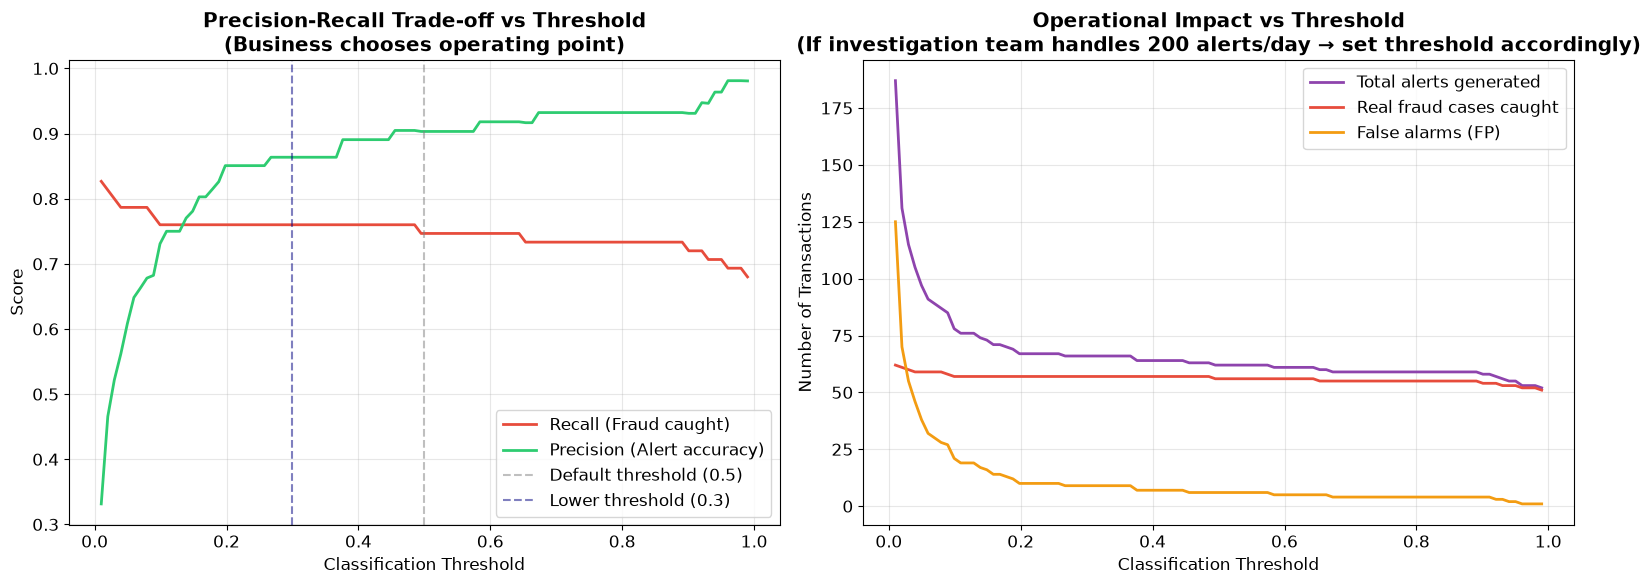

=== Operational Impact at Different Thresholds ===
 Threshold | Fraud Caught | False Alarms |   Recall |  Precision
------------------------------------------------------------
       0.1 |           57 |           21 |    0.760 |      0.731
       0.2 |           57 |           10 |    0.760 |      0.851
       0.3 |           57 |            9 |    0.760 |      0.864
       0.5 |           56 |            6 |    0.747 |      0.903
       0.7 |           55 |            4 |    0.733 |      0.932
       0.9 |           54 |            4 |    0.720 |      0.931


In [16]:
# ── Threshold analysis — business decision ──────────────────────────────────
# The threshold is not a modelling decision — it is a business decision.
# A fraud team with capacity to investigate N cases/day sets the threshold accordingly.

thresholds = np.linspace(0.01, 0.99, 100)
results_threshold = []

for t in thresholds:
    y_pred_t = (xgb_probs >= t).astype(int)
    tp = ((y_pred_t == 1) & (y_test == 1)).sum()
    fp = ((y_pred_t == 1) & (y_test == 0)).sum()
    fn = ((y_pred_t == 0) & (y_test == 1)).sum()
    total_fraud = (y_test == 1).sum()
    results_threshold.append({
        'threshold': t,
        'recall': tp / total_fraud if total_fraud > 0 else 0,
        'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
        'total_flagged': tp + fp,
        'fraud_caught': tp,
        'false_alarms': fp
    })

thresh_df = pd.DataFrame(results_threshold)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(thresh_df['threshold'], thresh_df['recall'],
             label='Recall (Fraud caught)', color=COLORS['fraud'], linewidth=2)
axes[0].plot(thresh_df['threshold'], thresh_df['precision'],
             label='Precision (Alert accuracy)', color=COLORS['legit'], linewidth=2)
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default threshold (0.5)')
axes[0].axvline(x=0.3, color='navy', linestyle='--', alpha=0.5, label='Lower threshold (0.3)')
axes[0].set_xlabel('Classification Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall Trade-off vs Threshold\n(Business chooses operating point)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(thresh_df['threshold'], thresh_df['total_flagged'],
             color='#8E44AD', linewidth=2, label='Total alerts generated')
axes[1].plot(thresh_df['threshold'], thresh_df['fraud_caught'],
             color=COLORS['fraud'], linewidth=2, label='Real fraud cases caught')
axes[1].plot(thresh_df['threshold'], thresh_df['false_alarms'],
             color='#F39C12', linewidth=2, label='False alarms (FP)')
axes[1].set_xlabel('Classification Threshold')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_title('Operational Impact vs Threshold\n(If investigation team handles 200 alerts/day → set threshold accordingly)', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Show what different thresholds mean operationally
print('=== Operational Impact at Different Thresholds ===')
print(f'{"Threshold":>10} | {"Fraud Caught":>12} | {"False Alarms":>12} | {"Recall":>8} | {"Precision":>10}')
print('-' * 60)
for t in [0.1, 0.2, 0.3, 0.5, 0.7, 0.9]:
    row = thresh_df[thresh_df['threshold'].between(t-0.005, t+0.005)].iloc[0]
    print(f'{row["threshold"]:>10.1f} | {int(row["fraud_caught"]):>12} | {int(row["false_alarms"]):>12} | {row["recall"]:>8.3f} | {row["precision"]:>10.3f}')

## 8. SHAP Explainability

In regulated banking, model risk teams require that individual predictions can be explained.
SHAP (SHapley Additive exPlanations) attributes each feature's contribution to a specific prediction.
This is essential for:
- Regulatory compliance and model risk governance
- Explaining to customers why a transaction was flagged
- Detecting whether the model has learned spurious patterns

Computing SHAP values (this may take a minute)...


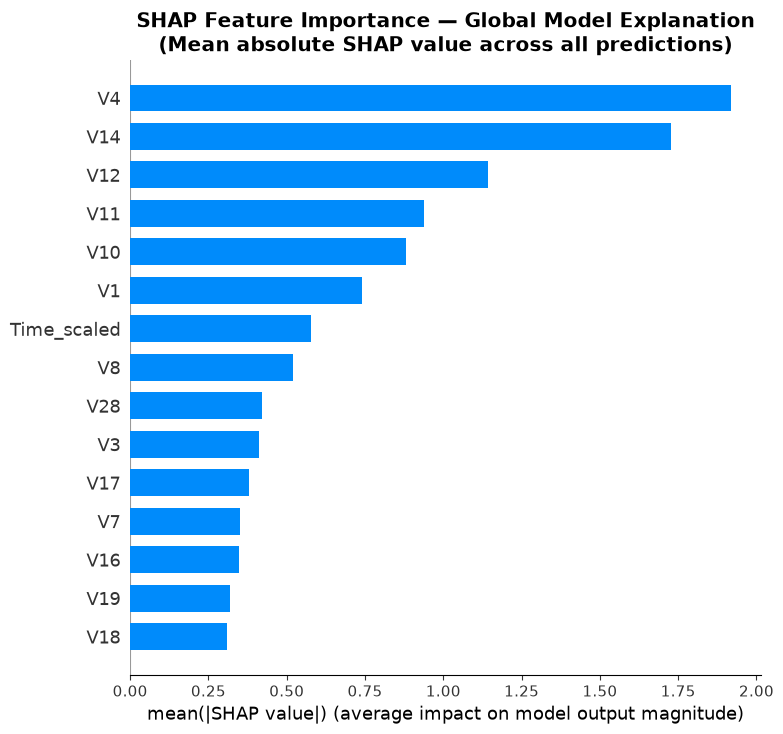

In [17]:
# ── SHAP values ─────────────────────────────────────────────────────────────
print('Computing SHAP values (this may take a minute)...')
explainer = shap.TreeExplainer(xgb_model)

# Use a sample for speed
sample_idx = np.random.choice(len(X_test), size=2000, replace=False)
X_sample   = X_test.iloc[sample_idx]
shap_values = explainer.shap_values(X_sample)

# Global feature importance — SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar',
                  show=False, max_display=15)
plt.title('SHAP Feature Importance — Global Model Explanation\n(Mean absolute SHAP value across all predictions)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

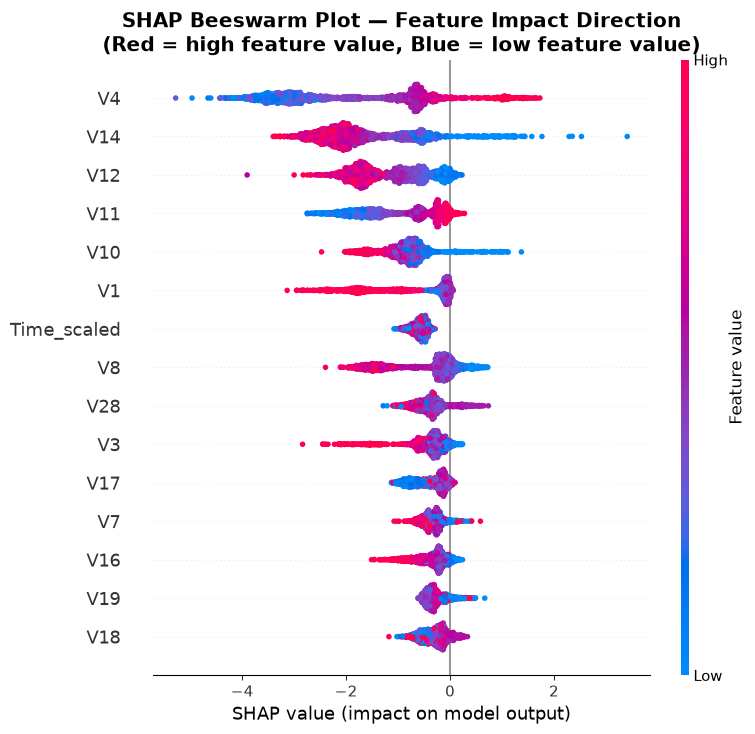

In [18]:
# ── SHAP beeswarm — shows direction of each feature's effect ───────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title('SHAP Beeswarm Plot — Feature Impact Direction\n(Red = high feature value, Blue = low feature value)',
          fontweight='bold')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── SHAP waterfall — explain ONE individual prediction ──────────────────────
# This is what you would show to a fraud investigator asking 'why was this flagged?'

# Find a fraud case in our sample
y_sample = y_test.iloc[sample_idx].reset_index(drop=True)
fraud_indices = y_sample[y_sample == 1].index

if len(fraud_indices) > 0:
    idx = fraud_indices[0]
    fraud_prob = xgb_probs[sample_idx[idx]]

    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_sample.iloc[idx].values,
            feature_names=X_sample.columns.tolist()
        ),
        show=False, max_display=12
    )
    plt.title(f'SHAP Waterfall — Individual Fraud Prediction\nPredicted fraud probability: {fraud_prob:.4f}\n(This explains WHY this specific transaction was flagged)',
              fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Banking context: This waterfall plot is what you show to:')
    print('  - A fraud investigator asking why a transaction was flagged')
    print('  - A model risk team requiring evidence of interpretability')
    print('  - A customer disputing why their payment was blocked')

## 9. Champion-Challenger Comparison

In production banking environments, you never simply replace one model with another.
You run a champion-challenger framework:
- **Champion**: current live model (Logistic Regression baseline)
- **Challenger**: new model being evaluated (XGBoost)
- Run both on the same test data and compare systematically before promoting

=== CHAMPION-CHALLENGER FRAMEWORK ===

Champion: Logistic Regression with class weights (current live model)
Challenger: XGBoost (proposed replacement)

--- At threshold = 0.3 ---
  Champion (LR)        | Recall: 0.907 | Precision: 0.032 | KS: 0.885 | PR-AUC: 0.761 | Alerts: 2,124
  Challenger (XGB)     | Recall: 0.760 | Precision: 0.864 | KS: 0.880 | PR-AUC: 0.802 | Alerts: 66

--- At threshold = 0.5 ---
  Champion (LR)        | Recall: 0.893 | Precision: 0.068 | KS: 0.885 | PR-AUC: 0.761 | Alerts: 991
  Challenger (XGB)     | Recall: 0.747 | Precision: 0.903 | KS: 0.880 | PR-AUC: 0.802 | Alerts: 62



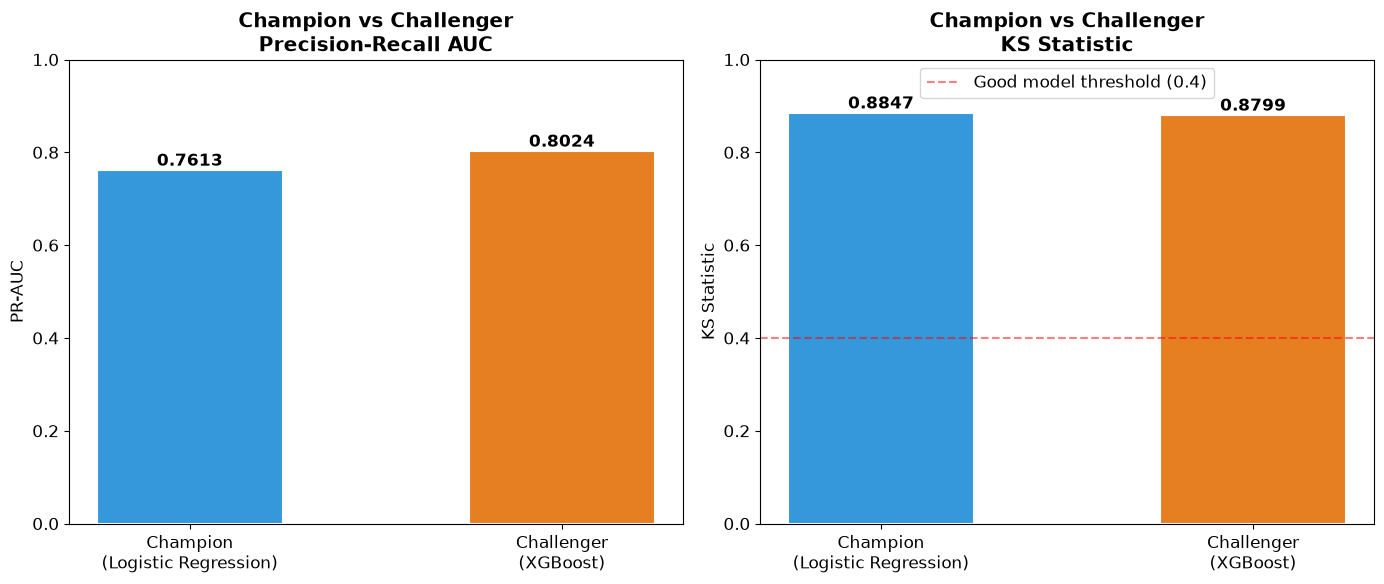

Recommendation: The Challenger (XGBoost) shows a 5.4% improvement in PR-AUC.
In a real deployment, this would trigger a formal promotion process:
  1. Model risk team validates the challenger on additional data cuts
  2. Challenger runs on 10% of live traffic (A/B test)
  3. After sufficient volume, compare KS and recall on confirmed fraud labels
  4. Formal sign-off before full promotion


In [20]:
# ── Champion-Challenger comparison ──────────────────────────────────────────
print('=== CHAMPION-CHALLENGER FRAMEWORK ===')
print()
print('Champion: Logistic Regression with class weights (current live model)')
print('Challenger: XGBoost (proposed replacement)')
print()

# Compare at two thresholds — default 0.5 and operational 0.3
for threshold in [0.3, 0.5]:
    print(f'--- At threshold = {threshold} ---')
    for model_name, probs in [('Champion (LR)', lr_probs), ('Challenger (XGB)', xgb_probs)]:
        y_pred = (probs >= threshold).astype(int)
        tp = ((y_pred==1) & (y_test==1)).sum()
        fp = ((y_pred==1) & (y_test==0)).sum()
        total_fraud = (y_test==1).sum()
        recall_val = tp / total_fraud
        prec_val   = tp / (tp+fp) if (tp+fp) > 0 else 0
        ks_val     = ks_statistic(y_test, probs)
        pr_auc_val = average_precision_score(y_test, probs)
        print(f'  {model_name:20s} | Recall: {recall_val:.3f} | Precision: {prec_val:.3f} | '
              f'KS: {ks_val:.3f} | PR-AUC: {pr_auc_val:.3f} | Alerts: {tp+fp:,}')
    print()

# Visualise champion vs challenger
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

models = ['Champion\n(Logistic Regression)', 'Challenger\n(XGBoost)']
pr_aucs = [results_lr['pr_auc'], results_xgb['pr_auc']]
ks_vals = [results_lr['ks'], results_xgb['ks']]

bars1 = axes[0].bar(models, pr_aucs, color=[COLORS['model1'], COLORS['model2']],
                    edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Champion vs Challenger\nPrecision-Recall AUC', fontweight='bold')
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('PR-AUC')
for bar, val in zip(bars1, pr_aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

bars2 = axes[1].bar(models, ks_vals, color=[COLORS['model1'], COLORS['model2']],
                    edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_title('Champion vs Challenger\nKS Statistic', fontweight='bold')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('KS Statistic')
axes[1].axhline(y=0.4, color='red', linestyle='--', alpha=0.5, label='Good model threshold (0.4)')
axes[1].legend()
for bar, val in zip(bars2, ks_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('champion_challenger.png', dpi=150, bbox_inches='tight')
plt.show()

improvement = (results_xgb['pr_auc'] - results_lr['pr_auc']) / results_lr['pr_auc'] * 100
print(f'Recommendation: The Challenger (XGBoost) shows a {improvement:.1f}% improvement in PR-AUC.')
print('In a real deployment, this would trigger a formal promotion process:')
print('  1. Model risk team validates the challenger on additional data cuts')
print('  2. Challenger runs on 10% of live traffic (A/B test)')
print('  3. After sufficient volume, compare KS and recall on confirmed fraud labels')
print('  4. Formal sign-off before full promotion')

## 10. Summary and Business Interpretation

In [21]:
# ── Final summary table ──────────────────────────────────────────────────────
summary = pd.DataFrame([
    {
        'Model': 'Logistic Regression (Class Weights)',
        'PR-AUC': f"{results_lr['pr_auc']:.4f}",
        'KS Stat': f"{results_lr['ks']:.4f}",
        'ROC-AUC': f"{results_lr['roc_auc']:.4f}",
        'Recall': f"{results_lr['recall']:.4f}",
        'Precision': f"{results_lr['precision']:.4f}",
        'Role': 'CHAMPION (Baseline)'
    },
    {
        'Model': 'Logistic Regression + SMOTE',
        'PR-AUC': f"{results_smote['pr_auc']:.4f}",
        'KS Stat': f"{results_smote['ks']:.4f}",
        'ROC-AUC': f"{results_smote['roc_auc']:.4f}",
        'Recall': f"{results_smote['recall']:.4f}",
        'Precision': f"{results_smote['precision']:.4f}",
        'Role': 'Comparison'
    },
    {
        'Model': 'XGBoost (scale_pos_weight)',
        'PR-AUC': f"{results_xgb['pr_auc']:.4f}",
        'KS Stat': f"{results_xgb['ks']:.4f}",
        'ROC-AUC': f"{results_xgb['roc_auc']:.4f}",
        'Recall': f"{results_xgb['recall']:.4f}",
        'Precision': f"{results_xgb['precision']:.4f}",
        'Role': 'CHALLENGER (Recommended)'
    },
])

print('=== FINAL MODEL COMPARISON ===')
print(summary.to_string(index=False))

print()
print('=== KEY DECISIONS MADE IN THIS PROJECT AND WHY ===')
print()
print('1. CHRONOLOGICAL split (not random)')
print('   → Random splits leak future transactions into training — a form of data leakage')
print('   → In production, the model only ever sees past data')
print()
print('2. PR-AUC as PRIMARY metric (not accuracy)')
print('   → A model predicting all transactions as legitimate = 99.83% accuracy but 0% recall')
print('   → PR-AUC is informative even when positive class is very rare')
print()
print('3. KS statistic reported alongside PR-AUC')
print('   → Standard banking model validation metric used by model risk teams')
print('   → KS > 0.4 indicates good model discrimination')
print()
print('4. Class weights PREFERRED over SMOTE')
print('   → Synthetic fraud transactions may not reflect real fraud behaviour')
print('   → In regulated banking, class weights are the cleaner, more defensible approach')
print()
print('5. SHAP explainability built in from the start')
print('   → Required for model risk governance in a regulated bank')
print('   → Enables fraud investigators to understand individual flagged transactions')
print()
print('6. THRESHOLD as a BUSINESS decision, not a modelling decision')
print('   → The threshold depends on investigation team capacity and fraud harm profile')
print('   → The modeller presents the trade-off curve; the business chooses the operating point')
print()
print('7. CHAMPION-CHALLENGER framework demonstrated')
print('   → Models are never simply replaced — challengers are tested alongside champions')
print('   → Reduces risk of deploying a worse model to production')

=== FINAL MODEL COMPARISON ===
                              Model PR-AUC KS Stat ROC-AUC Recall Precision                     Role
Logistic Regression (Class Weights) 0.7613  0.8847  0.9861 0.8933    0.0676      CHAMPION (Baseline)
        Logistic Regression + SMOTE 0.7700  0.8937  0.9857 0.8800    0.0656               Comparison
         XGBoost (scale_pos_weight) 0.8024  0.8799  0.9789 0.7467    0.9032 CHALLENGER (Recommended)

=== KEY DECISIONS MADE IN THIS PROJECT AND WHY ===

1. CHRONOLOGICAL split (not random)
   → Random splits leak future transactions into training — a form of data leakage
   → In production, the model only ever sees past data

2. PR-AUC as PRIMARY metric (not accuracy)
   → A model predicting all transactions as legitimate = 99.83% accuracy but 0% recall
   → PR-AUC is informative even when positive class is very rare

3. KS statistic reported alongside PR-AUC
   → Standard banking model validation metric used by model risk teams
   → KS > 0.4 indicates good